In [1]:
# %run validation_experiment.py --lr 1e-4 --epoch 2 --repeat 8

In [2]:
# %run validation_experiment.py

In [3]:
# for ex in train_dataset.select(explanation.documents):
#     for msg in ex["messages"]:
#         if msg["role"] == "assistant":
#             print(len(msg["content"].split()))

In [4]:
# import torch
# import pandas as pd
# import os

# from validation_engine import ValidationEngine
# from load_experiment_data import (
#     load_data_and_estimators,
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
# )
# from explanations import Self, KRandom

# torch.manual_seed(42)


# train_dataset, test_dataset, estimators = load_data_and_estimators()
# estimator = estimators[1]  
# print("Using estimator:", estimator.model_path)


In [5]:

# # Init engine for this estimator
# engine = ValidationEngine(estimator.model_path)

# # Pick a single explanation (e.g., "Self" with k=1 for the first test document)
# explanation = Self(1, estimator, k=1)

# # Prepare train + test examples
# examples_to_train_on = train_dataset.select(explanation.documents)
# indices_to_train_on = explanation.documents
# examples_to_test_on = test_dataset.select([explanation.document_idx])
# indices_to_test_on = [explanation.document_idx]

# engine.score(examples_to_train_on, examples_to_test_on, seed=42)

In [6]:
# idx = 0
# # Init engine for this estimator
# engine = ValidationEngine(estimator.model_path,lr=1e-10, epochs=1)

# explanation = Self(idx, estimator, k=1)


# examples_to_train_on = train_dataset.select(explanation.documents)
# indices_to_train_on = explanation.documents
# examples_to_test_on = test_dataset.select([explanation.document_idx])
# indices_to_test_on = [explanation.document_idx]

# delta_selection = engine.score(examples_to_train_on, examples_to_test_on, seed=42)


# explanation = KRandom(idx, estimator, k=1)

# examples_to_train_on = train_dataset.select(explanation.documents)
# indices_to_train_on = explanation.documents
# examples_to_test_on = test_dataset.select([explanation.document_idx])
# indices_to_test_on = [explanation.document_idx]

# delta_random = engine.score(examples_to_train_on, examples_to_test_on, seed=42)
# print(delta_selection, delta_random, delta_selection >= delta_random)


In [7]:
# df.groupby(["Kind", "LR", "Epoch"]).mean()

In [8]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Load the data
# parquet_file = "cache/validation_of_validation/deltasn5.parquet"
# df = pd.read_parquet(parquet_file)
# df = df[df["LR"] != 1]

# # Ensure 'Repeat' exists (or use your Index column)
# if "Repeat" not in df.columns:
#     df = df.rename(columns={"Index": "Repeat"})

# # Convert LR and Epoch to strings for nicer facet labels
# df["LR_str"] = df["LR"].astype(str)
# df["Epoch_str"] = df["Epoch"].astype(str)

# # Create a facet plot: rows = LR, cols = Epoch
# g = sns.catplot(
#     data=df,
#     x="Repeat",
#     y="KL",
#     hue="Kind",
#     row="LR_str",
#     col="Epoch_str",
#     kind="box",
#     height=4,
#     aspect=1.2,
#     dodge=True,
#     showfliers=False,
#     showcaps=True
# )

# # Add a horizontal line at 0 in each subplot
# for ax in g.axes.flatten():
#     ax.axhline(0, color="black", linestyle=":")

# # Set axis labels
# g.set_axis_labels("Repeat", "Δ log-prob (per test document)")

# # Set facet titles
# g.set_titles(row_template="LR={row_name}", col_template="Epoch={col_name}")

# # Adjust legend
# g.add_legend(title="Kind")

# plt.tight_layout()
# plt.show()


# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.read_parquet(parquet_file)
# df = df[df["LR"] != 1]

# df_wide = df.pivot_table(
#     index=["LR", "Repeat", "Index","Epoch"],  
#     columns="Kind",
#     values="KL"
# ).reset_index()


# df_wide["winner"] = df_wide["exact"] >= df_wide["random"]
# df_wide["winner_ood"] = df_wide["exact"] >= df_wide["ood"]


# pivoted = df_wide.groupby(["LR", "Repeat","Epoch"])[["exact", "random","ood",]].mean().reset_index()
# pivoted["winner_fraction_vs_random"] = df_wide.groupby(["LR", "Repeat","Epoch"])["winner"].mean().values  
# pivoted["winner_fraction_vs_ood"] = df_wide.groupby(["LR", "Repeat","Epoch"])["winner_ood"].mean().values  
# pivoted["count"] = df_wide.groupby(["LR", "Repeat","Epoch"])["winner"].count().values  

# pivoted


######## delta_log_p #############


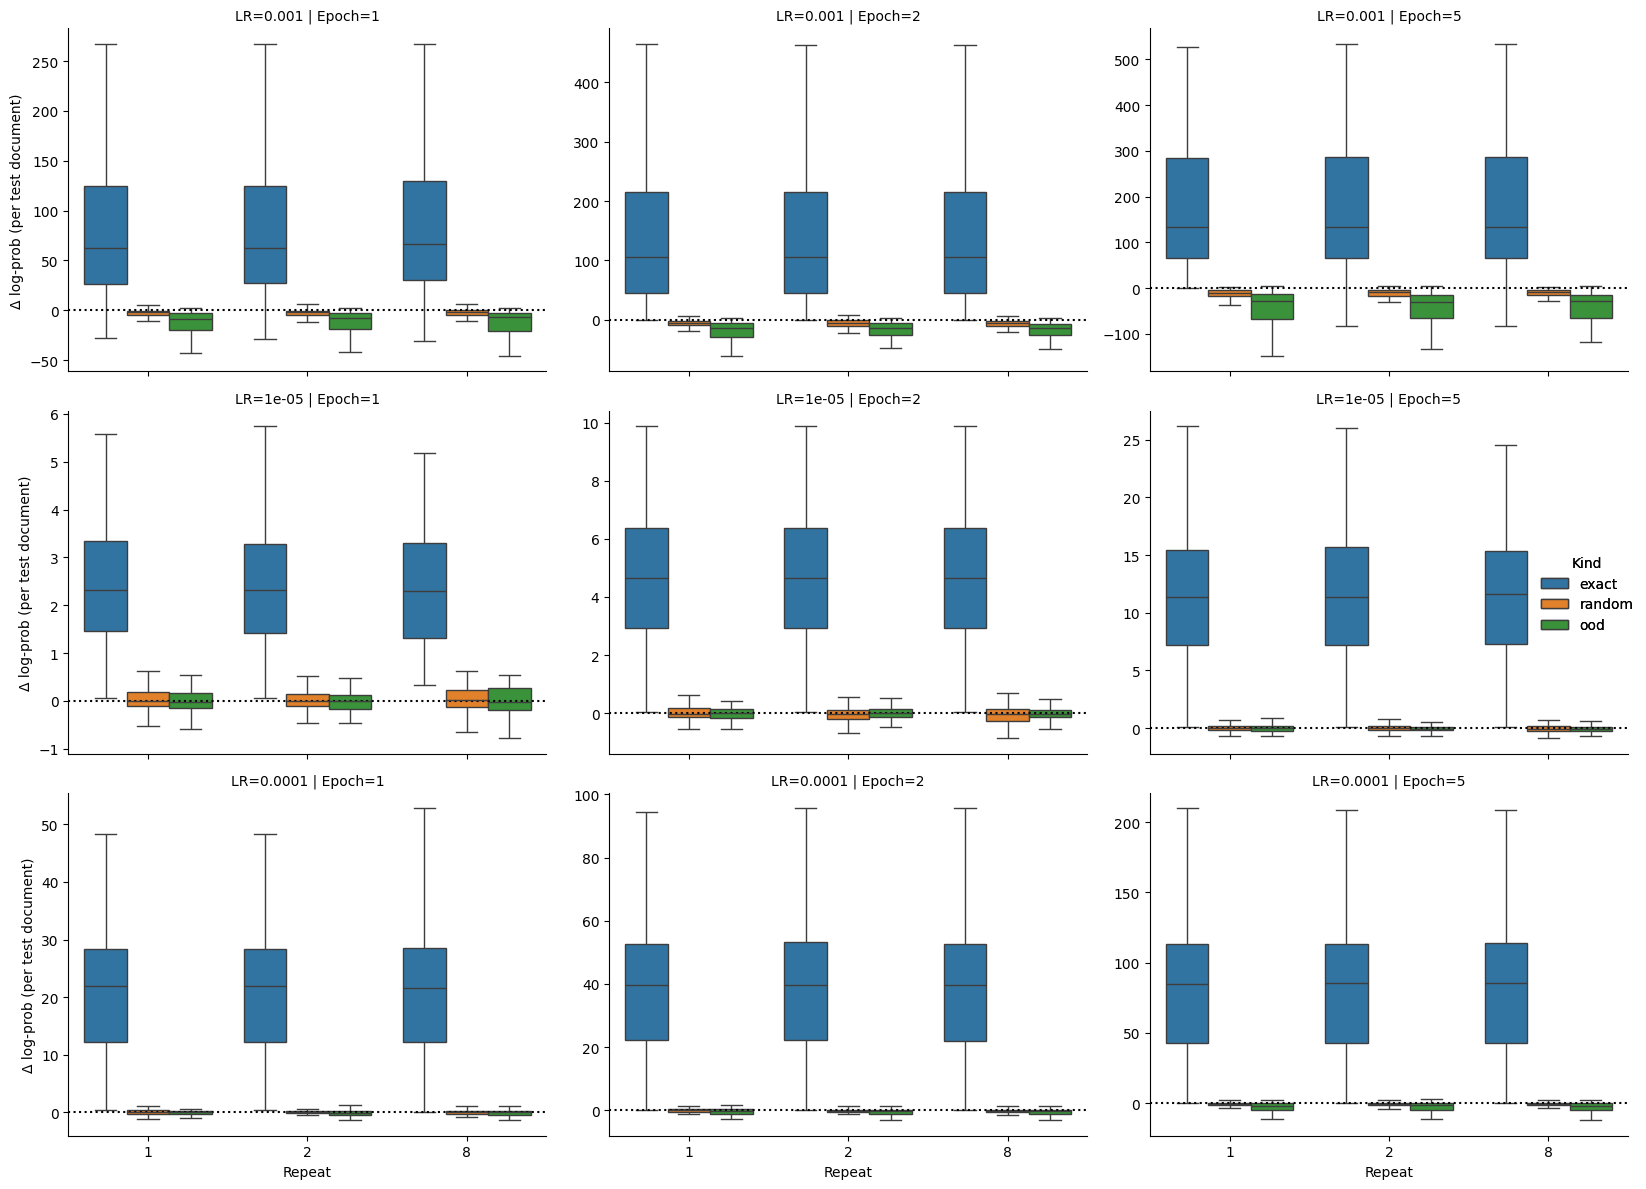

######## jsd #############


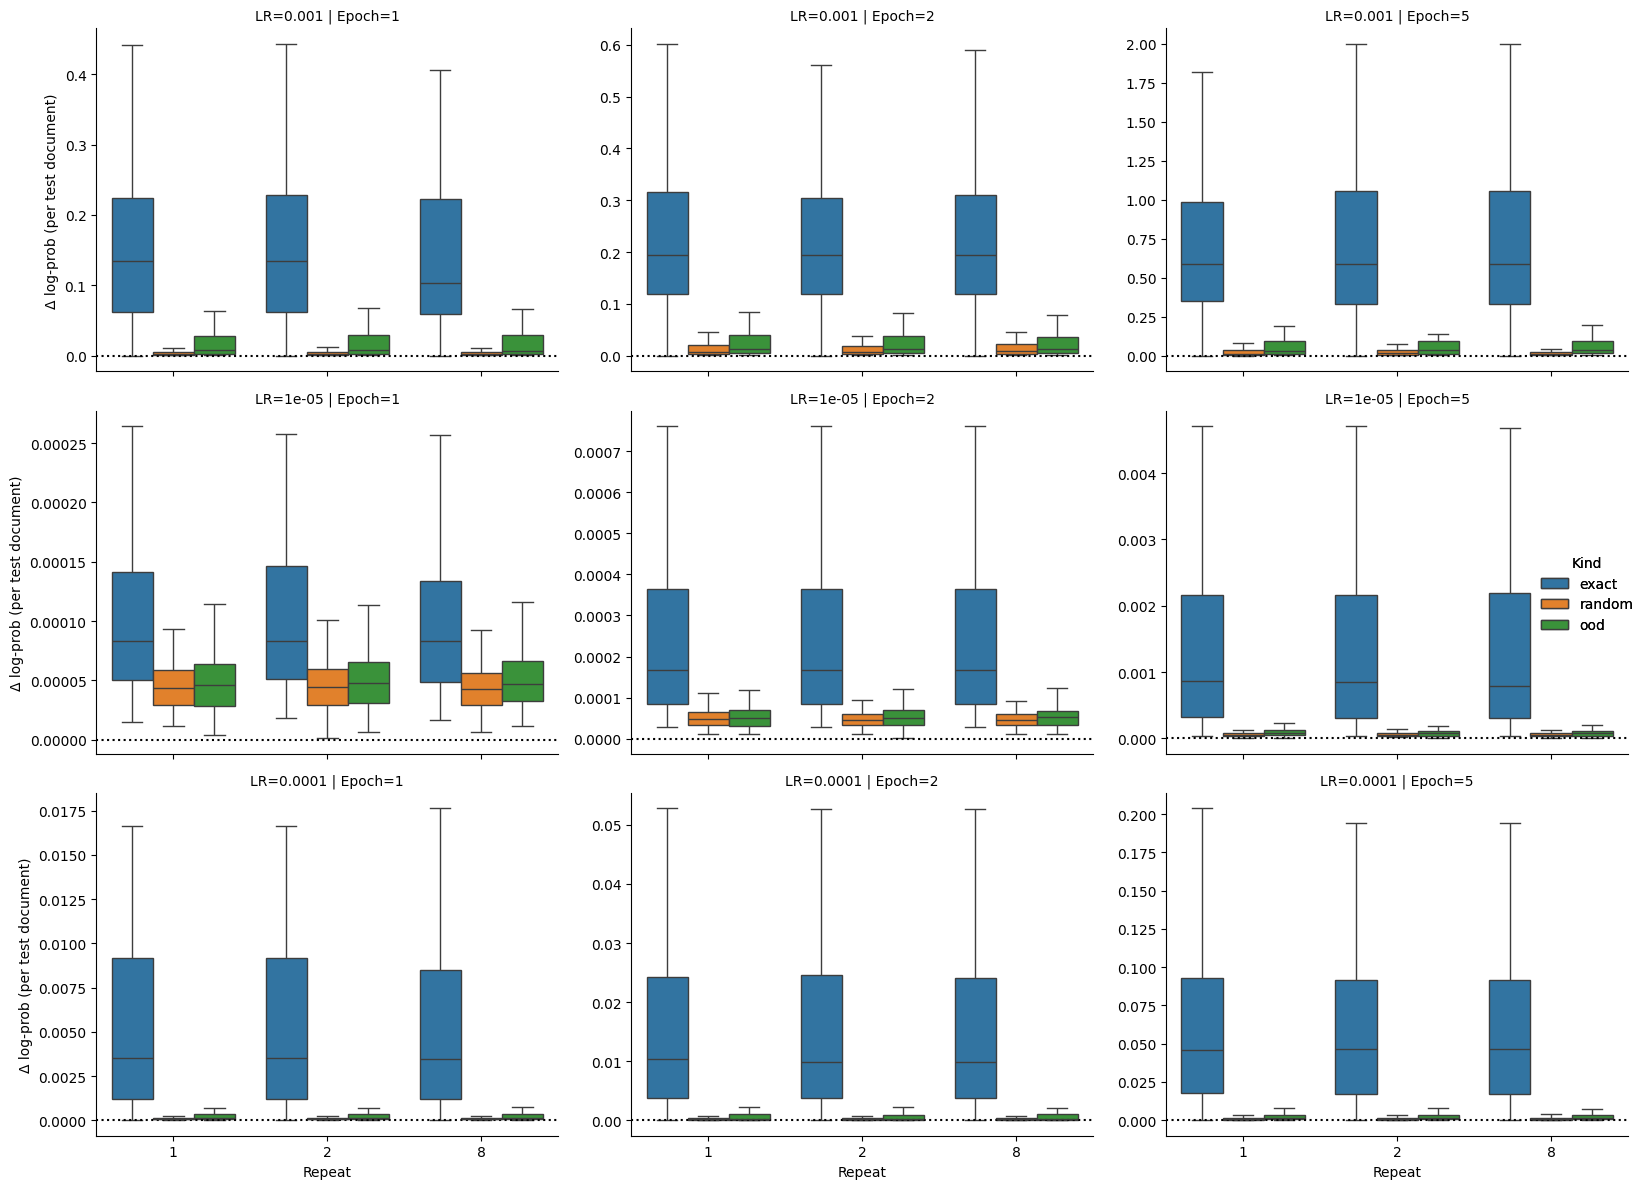

######## kld(before||after) #############


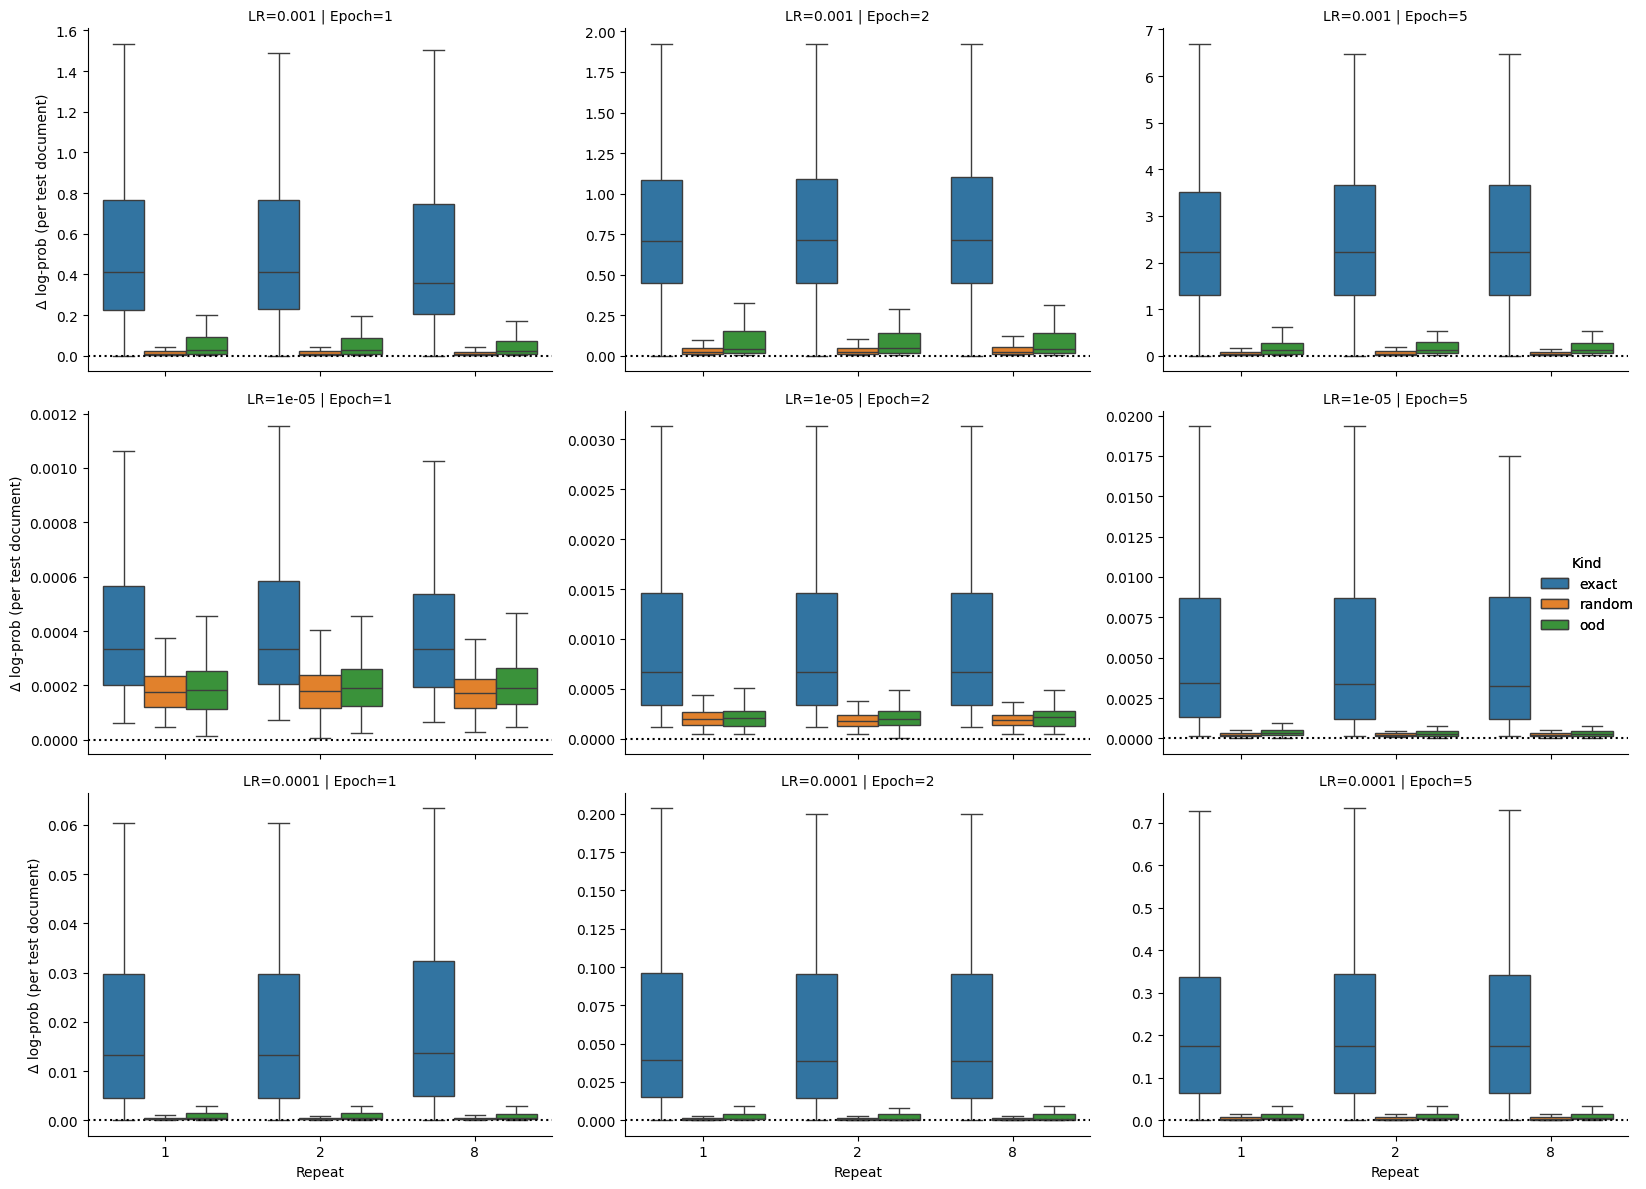

,\rotatebox{45}{LR},\rotatebox{45}{\# duplicated},\rotatebox{45}{Epochs},\rotatebox{45}{$\Delta \log p (x)$},\rotatebox{45}{$\Delta \log p (\mathrm{random})$},\rotatebox{45}{$\Delta \log p (\mathrm{ood})$},\rotatebox{45}{$\mathrm{JSD}(x)$},\rotatebox{45}{$\mathrm{JSD}(\mathrm{random})$},\rotatebox{45}{$\mathrm{JSD}(\mathrm{ood})$},\rotatebox{45}{$\mathbb{I}[\Delta \log p(x) \geq \Delta \log p(\mathrm{random})]$},\rotatebox{45}{$\mathbb{I}[\Delta \log p(x) \geq \Delta \log p(\mathrm{ood})]$}
0,1e-5,1,1,2.518155,0.000988,-0.031246,0.000112,0.000050,0.000049,1.00 ± 0.00,1.00 ± 0.00
1,1e-5,1,2,4.904204,0.009281,-0.001834,0.000283,0.000055,0.000058,0.99 ± 0.02,1.00 ± 0.00
2,1e-5,1,5,11.826279,0.042792,-0.039460,0.001376,0.000084,0.000103,0.98 ± 0.03,0.99 ± 0.02
3,1e-5,2,1,2.517368,-0.024235,-0.062707,0.000112,0.000050,0.000049,1.00 ± 0.00,1.00 ± 0.00
4,1e-5,2,2,4.904204,-0.025793,-0.027124,0.000283,0.000053,0.000058,0.99 ± 0.02,0.99 ± 0.02
5,1e-5,2,5,11.837700,-0.015425,-0.091478,0.001379,0.000080,0.000104,1.00 ± 0.00,0.99 ± 0.02
6,1e-5,8,1,2.413030,0.041199,0.036870,0.000111,0.000047,0.000051,1.00 ± 0.00,1.00 ± 0.00
7,1e-5,8,2,4.904204,-0.051946,-0.027348,0.000283,0.000054,0.000058,0.99 ± 0.02,0.99 ± 0.02
8,1e-5,8,5,11.794816,-0.049856,-0.056061,0.001384,0.000082,0.000103,0.99 ± 0.02,1.00 ± 0.00
9,1e-4,1,1,21.301002,-0.015079,-0.119601,0.005739,0.000160,0.000287,0.99 ± 0.03,1.00 ± 0.00


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
# --- Load data ---
parquet_folder = Path("cache/validation_of_validation")
parquet_files = list(parquet_folder.rglob("*.parquet"))

df = pd.read_parquet(parquet_files)
df = df[df["LR"] != 1]

df["LR_str"] = df["LR"].astype(str)
df["Epoch_str"] = df["Epoch"].astype(str)

# --- Visualization (optional, same as before) ---
for col in ["delta_log_p", "jsd", "kld(before||after)"]:
    
    print(f"######## {col} #############")
    g = sns.catplot(
        data=df,
        x="Repeat",
        y=col,
        hue="Kind",
        row="LR_str",
        col="Epoch_str",
        kind="box",
        height=4,
        aspect=1.2,
        sharey=False,
        dodge=True,
        showfliers=False,
        showcaps=True
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="black", linestyle=":")
    g.set_axis_labels("Repeat", "Δ log-prob (per test document)")
    g.set_titles(row_template="LR={row_name}", col_template="Epoch={col_name}")
    g.add_legend(title="Kind")
    plt.tight_layout()
    plt.show()

# --- Pivot all metrics into wide form ---
df_wide = df.pivot_table(
    index=["LR", "Repeat", "Index", "Epoch"],
    columns=["Kind"],
    values=["delta_log_p", "jsd", "kld(before||after)"]
)

# flatten multiindex columns
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns.values]
df_wide = df_wide.reset_index()

# --- Compute "winner" stats based only on delta_log_p ---
df_wide["winner_vs_random"] = df_wide["delta_log_p_exact"] >= df_wide["delta_log_p_random"]
df_wide["winner_vs_ood"] = df_wide["delta_log_p_exact"] >= df_wide["delta_log_p_ood"]

grouped = df_wide.groupby(["LR", "Repeat", "Epoch"])

# --- Aggregate everything ---
pivoted = grouped[
    [
        "delta_log_p_exact", "delta_log_p_random", "delta_log_p_ood",
        "jsd_exact", "jsd_random", "jsd_ood",
        # "kld(before||after)_exact", "kld(before||after)_random", "kld(before||after)_ood"
    ]
].mean().reset_index()

# pivoted["winner_fraction_vs_random"] = grouped["winner_vs_random"].mean().values
# pivoted["winner_fraction_vs_ood"] = grouped["winner_vs_ood"].mean().values
# pivoted["winner_variance_vs_random"] = grouped["winner_vs_random"].var().values
# pivoted["winner_variance_vs_ood"] = grouped["winner_vs_ood"].var().values
# pivoted["count"] = grouped["winner_vs_random"].count().values

def mean_ci_95(series):
    n = series.count()
    mean = series.mean()
    ci95 = 1.96 * np.sqrt(mean * (1 - mean) / n) if n > 0 else 0.0
    return f"{mean:.2f} ± {ci95:.2f}"

# Compute "winner mean ± std"
winner_stats = grouped[["winner_vs_random", "winner_vs_ood"]].apply(lambda x: x.apply(mean_ci_95)).reset_index()
# Flatten multiindex
# winner_stats.columns = [f"{col}_mean_std" for col in winner_stats.columns]

# Convert to "mean ± std" strings
pivoted["winner_vs_random"] = winner_stats["winner_vs_random"].values
pivoted["winner_vs_ood"] = winner_stats["winner_vs_ood"].values

pivoted_sorted = pivoted.sort_values(by=["LR", "Repeat", "Epoch"])
import numpy as np
pivoted_sorted["LR"] = pivoted_sorted["LR"].apply(lambda x: f"1e{int(np.log10(x))}")

pivoted_sorted = pivoted_sorted.rename(columns={
    "delta_log_p_exact": r"$\Delta \log p (x)$",
    "delta_log_p_random": r"$\Delta \log p (\mathrm{random})$",
    "delta_log_p_ood": r"$\Delta \log p (\mathrm{ood})$",
    
    "jsd_exact": r"$\mathrm{JSD}(x)$",
    "jsd_random": r"$\mathrm{JSD}(\mathrm{random})$",
    "jsd_ood": r"$\mathrm{JSD}(\mathrm{ood})$",
    
    # "kld(before||after)_exact": r"$\mathrm{KLD}(\mathrm{b}\|\mathrm{a}), x$",
    # "kld(before||after)_random": r"$\mathrm{KLD}(\mathrm{b}\|\mathrm{a}), \mathrm{random}$",
    # "kld(before||after)_ood": r"$\mathrm{KLD}(\mathrm{b}\|\mathrm{a}, \mathrm{ood})$",
    
    "winner_vs_random": r"$\mathbb{I}[\Delta \log p(x) \geq \Delta \log p(\mathrm{random})]$",
    
    "winner_vs_ood": r"$\mathbb{I}[\Delta \log p(x) \geq \Delta \log p(\mathrm{ood})]$",
    "Repeat": "\# duplicated",
    "Epoch": "Epochs"
})



pivoted_sorted.columns = [
    f"\\rotatebox{{45}}{{{col}}}" 
    for col in pivoted_sorted.columns
]

display(pivoted_sorted)

# --- Export LaTeX ---
Path("tables").mkdir(exist_ok=True)
num_cols = len(pivoted_sorted.columns)

latex_table = pivoted_sorted.to_latex(
    index=False,
    float_format="%.2f",
    longtable=True,
    column_format="c" * num_cols ,
    escape=False
)

with open("tables/validation_of_validation_results.tex", "w") as f:
    f.write(latex_table)



In [ ]:
df_exact = df[df["Kind"] == "exact"]
df_random = df[df["Kind"] == "random"]

df_exact_random = df_exact.merge(
    df_random,
    on=["LR", "Epoch", "Repeat"],
    suffixes=("_exact", "_random")
)

df_exact_random = df_exact_random[[
    "LR", "Epoch", "Repeat",
    "Index_exact", "Delta_exact", "log_p_before_exact", "log_p_after_exact",
    "Index_random", "Delta_random", "log_p_before_random", "log_p_after_random"
]]

df_exact_random["winner"] = df_exact_random["Delta_exact"] >= df_exact_random["Delta_random"]

pivoted = df_exact_random.groupby(["LR", "Repeat","Epoch"])[["Delta_exact", "Delta_random"]].mean().reset_index()
pivoted["winner_fraction_vs_random"] = df_exact_random.groupby(["LR", "Repeat","Epoch"])["winner"].mean().values  
pivoted["count"] = df_exact_random.groupby(["LR", "Repeat","Epoch"])["winner"].count().values  

pivoted

In [ ]:

df_exact_ood = df_exact.merge(
    df_ood,
    on=["LR", "Epoch", "Repeat"],
    suffixes=("_exact", "_ood")
)

df_exact_ood = df_exact_ood[[
    "LR", "Epoch", "Repeat",
    "Index_exact", "Delta_exact", "log_p_before_exact", "log_p_after_exact",
    "Index_ood", "Delta_ood", "log_p_before_ood", "log_p_after_ood"
]]


df_exact_ood["winner"] = df_exact_ood["Delta_exact"] >= df_exact_ood["Delta_ood"]

pivoted_exact_ood = df_exact_ood.groupby(["LR", "Repeat", "Epoch"])[["Delta_exact", "Delta_ood"]].mean().reset_index()
pivoted_exact_ood["winner_fraction_vs_ood"] = df_exact_ood.groupby(["LR", "Repeat", "Epoch"])["winner"].mean().values
pivoted_exact_ood["count"] = df_exact_ood.groupby(["LR", "Repeat", "Epoch"])["winner"].count().values

print("Exact vs OOD pivoted:")
pivoted_exact_ood

In [ ]:
pivoted

In [ ]:
5346543iuh

In [ ]:
import os
from multiprocess import set_start_method
set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [ ]:


from coreset_trainer.trainer import CoresetTrainer
import os
import torch

import argparse



In [ ]:
from load_experiment_data import (
    train_dataset_name,
    test_dataset_name,
    train_dataset_split,
    test_dataset_split,
    load_data_and_estimators,
    explanation_types,
    linear_coders,
    explanation_seed,
    explanation_k
)
# train_dataset, test_dataset, estimators = load_data_and_estimators()


In [ ]:
from functools import partial
from explanations import KRandom
k_random_types = [partial(KRandom, seed=s) for s in range(9)]
explanation_types = explanation_types + k_random_types

In [ ]:
import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import multiprocessing
from tqdm import tqdm
import itertools
import pandas as pd
import traceback

logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
multiprocessing.set_start_method('spawn', force=True)
torch.manual_seed(42)




num_devices = torch.cuda.device_count()







In [ ]:
# import dask.dataframe as dd
# from dask.distributed import Client, LocalCluster


# cluster = LocalCluster(
#     n_workers=32,              
#     threads_per_worker=2,     
#     memory_limit='8.75GB',     
# )
# client = Client(cluster)
# client

In [ ]:

# device_ids = itertools.cycle(range(num_devices))
# results = []

# from peft import LoraConfig, get_peft_model, PeftModel


# for estimator in estimators:
    

#     explanations = [
#         explanation_type(row.name, estimator)
#         for explanation_type in explanation_types
#         for _, row in estimator.influence_estimate.iloc[test_indices].iterrows()
#     ]
            
        
#     partial_results_dir =  os.path.join("./cache/validation/partial/",
#         estimator.get_config_string(),
#         os.path.basename(estimator.model_path),
#         train_dataset_name,
#         train_dataset_split,
#         test_dataset_name,
#         test_dataset_split,
#         "partial")
#     with ProcessPoolExecutor(max_workers=2*num_devices) as executor:
#         futures = {}
#         for seed in range(1):
#             for ii, explanation in enumerate(explanations):
                
#                 # # random documents to test log_p for in addition to the document beeing explained
#                 # random_test_indices = test_dataset.shuffle(seed=ii).shuffle(seed=seed).select(range(explanation.k))["indices"]
            
#                 text_indices = [explanation.document_idx] #+ random_test_indices
#                 futures[explanation] = executor.submit(
#                         process,
#                         partial_results_dir,
#                         estimator, explanation,
#                         train_dataset.select(explanation.documents), explanation.documents, 
#                         test_dataset.select(text_indices), text_indices,                 
#                         train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split, 
#                         next(device_ids),
#                         seed,
#                         ii
#                 )

#         with tqdm(total=len(futures), desc="Explanations", position=0) as pbar:
#             for future in as_completed(futures.values()):
#                 try:
#                     future.result()  
#                 except Exception as e:
#                     logging.error(f"A future failed: {e}\n{traceback.format_exc()}")
#                     raise
#                 finally:
#                     pbar.update(1)

In [ ]:
# import os
# import subprocess
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm import tqdm

# def copy_folders(folders, local_root="/tmp", max_workers=32):
#     def copy_file(src_file, src_root, dst_root):
#         rel_path = os.path.relpath(src_file, src_root)
#         dst_file = os.path.join(dst_root, rel_path)
#         if os.path.exists(dst_file):
#             return
#         os.makedirs(os.path.dirname(dst_file), exist_ok=True)
#         try:
#             subprocess.run(["cp", "-p", src_file, dst_file], check=True)
#         except subprocess.CalledProcessError as e:
#             print(f"Error copying {src_file} to {dst_file}: {e}")

#     def chunks(lst, n):
#         k, m = divmod(len(lst), n)
#         return [lst[i*k + min(i, m):(i+1)*k + min(i+1, m)] for i in range(n)]

#     for remote_folder in folders:
#         local_folder = os.path.join(local_root, os.path.basename(remote_folder))
#         os.makedirs(remote_folder, exist_ok=True)
#         os.makedirs(local_folder, exist_ok=True)
#         all_files = [os.path.join(root, f) for root, _, files in os.walk(remote_folder) for f in files]
#         file_batches = chunks(all_files, max_workers)

#         def worker_copy(batch):
#             for f in batch:
#                 copy_file(f, remote_folder, local_folder)

#         with ThreadPoolExecutor(max_workers=max_workers) as executor:
#             futures = [executor.submit(worker_copy, batch) for batch in file_batches]
#             with tqdm(total=len(futures), desc=f"Copying {remote_folder}") as pbar:
#                 for future in as_completed(futures):
#                     future.result()
#                     pbar.update(1)


# # copy_folders(["cache/scoring", "cache/validation"], local_root="/tmp", max_workers=32)


In [ ]:
import glob
import pandas as pd
import os

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

In [ ]:
df_validation = pq.ParquetDataset("results/validation").read().to_pandas()


In [ ]:
# df_scoring = merge_fragments_with_source_column_parallel( source_dir="cache/scoring/partial", target_dir="results/scoring")
# # df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [ ]:
# df_scoring = load_or_merge_dataset( source_dir="cache/scoring/partial", target_dir="cache/scoring/full")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [ ]:
# df_scoring = load_or_merge_dataset(
#     source_dir="cache/scoring/partial",
#     target_dir="cache/scoring/full"
# )


# df_scoring["linear_coder"] = df_scoring["source_file"].apply(
#     lambda path: os.path.basename(os.path.dirname(os.path.dirname(path)))
# )

In [ ]:
(len(explanation_k) * (len(explanation_types) + len(explanation_seed))) + 1

In [ ]:
import re

In [ ]:
import re

def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))
    return None

df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
import re

def replace_k_with_X(explanation_type):

    explanation_type = re.sub(r"Top-(\d+)", "Top-X", explanation_type)

    explanation_type = re.sub(r"(\d+)\s+random examples", "X random examples", explanation_type)
    return explanation_type



In [ ]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]


In [ ]:
df_validation_selection.groupby("explanation_type").mean(numeric_only=True)

In [ ]:
df_validation_random.groupby("explanation_type").mean(numeric_only=True)

In [ ]:
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score"] = r["delta_target_document_selection"] >= r["delta_target_document_random"]
r.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                ]).agg(
                    mean_validation_score=("validation_score", "mean"),
                    count_validation_score=("validation_score", "count"))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate only over other dimensions, keeping k and explanation_type_selection
agg_df = r.groupby(
    ["estimator", "explanation_type_no_k", "k"]
).agg(
    mean_validation_score=("validation_score", "mean"),
    count_validation_score=("validation_score", "count")
).reset_index()

# Lineplot with facets for explanation_type_selection
g = sns.FacetGrid(
    agg_df, 
    col="explanation_type_no_k", 
    hue="estimator", 
    col_wrap=3,  # adjust as needed
    height=4,
    sharey=True
)
g.map(sns.lineplot, "k", "mean_validation_score", marker="o")
g.add_legend()
g.set_axis_labels("k", "Mean Validation Score")
plt.show()


In [ ]:
assert df_validation_random["explanation_type"].nunique() == (len(explanation_k) * (len(explanation_seed)))

In [ ]:
df_validation_selections["explanation_type"].nunique()

In [ ]:
df_validation_selections["explanation_type"].unique()

In [ ]:
(len(explanation_k) * (len(explanation_types)))+1

In [ ]:
explanation_k

In [ ]:
df_validation_random["explanation_type"].unique()

In [ ]:
ghifjo0dvo

In [ ]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random")]
# df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_selections = df_validation[~df_validation["explanation_type"].str.contains("random")]
df_validation_selections = df_validation_selections.drop(columns=["indices_trained_on"])




In [ ]:
# df_scoring_random = df_scoring[df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_random = df_scoring_random.drop(columns=["indices_trained_on"])
# df_scoring_selections = df_scoring[~df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_selections = df_scoring_selections.drop(columns=["indices_trained_on"])

In [ ]:
# df_scoring_random[df_scoring_random["explanation_type"] == "1 random examples with seed 42"]["mse"].mean()

In [ ]:
df_validation_selections.groupby("explanation_type").count()

In [ ]:
df_validation_selections.groupby("explanation_type").nunique()

In [ ]:
df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_random

In [ ]:
import re
import pandas as pd

pattern = r"Top-(\d+)"
group_cols = [
    "model",
    "estimator",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    # "LESSEstimator: normalize",
    "document_idx"
]

results = []
for linear_coder in linear_coders:
    linear_coder = linear_coder.__name__
    for explanation_type in df_validation_selections["explanation_type"].unique():
        k = int(re.match(pattern, explanation_type).group(1)) if "The test instance (as a sanity check)" not in explanation_type else 1

        # Only random runs matching this k
        random_run_names = df_validation_random[
            df_validation_random["explanation_type"].str.contains(f"{k} random")
        ]["explanation_type"].unique()

        for random_run_name in random_run_names:

            # Filter and drop duplicate rows per document
            sel = df_validation_selections[(df_validation_selections["explanation_type"] == explanation_type)]
            rnd = df_validation_random[(df_validation_random["explanation_type"] == random_run_name)]
            scores_sel = df_scoring_selections[(df_scoring_selections["explanation_type"] == explanation_type) & (df_scoring_selections["linear_coder"] == linear_coder)]
            scores_rnd = df_scoring_random[(df_scoring_random["explanation_type"] == random_run_name) &(df_scoring_random["linear_coder"] == linear_coder)]

            # Merge selection and random results on group_cols
            r = pd.merge(
                sel,
                rnd,
                on=group_cols,
                suffixes=("_selection", "_random"),
                how="inner"
            )

            # Merge pred_gain columns
            r = pd.merge(
                r,
                scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}),
                on=group_cols,
                how="left"
            )
            r = pd.merge(
                r,
                scores_rnd[group_cols + ["pred_gain","mse"]].rename(columns={"pred_gain": "pred_gain_random", "mse": "mse_random"}),
                on=group_cols,
                how="left"
            )



            if len(r) == 0:
                continue
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].nunique())
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].count())
            # display(len(scores_sel))
            # display(scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}).count())
            # raise Error

            # Compute summary statistics per random run
            results.append({
                "linear_coder": linear_coder,
                "explanation_type": explanation_type,
                "random_run": random_run_name,
                "k": k,
                "validation_score": (r["delta_target_document_selection"] >= r["delta_target_document_random"]).mean(skipna=True),
                "pred_gain_selection": r["pred_gain_selection"].mean(skipna=True),
                "pred_gain_random": r["pred_gain_random"].mean(skipna=True),
                "mse_selection": r["mse_selection"].mean(skipna=True),
                "mse_random": r["mse_random"].mean(skipna=True),
                "count": len(r),
                **r.iloc[0][[col for col in group_cols if col != "document_idx"]].to_dict(),
            })
            


results_df = pd.DataFrame(results)
results_df


In [ ]:
results_df.groupby(["linear_coder", "explanation_type","model","estimator"]).mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_rel

results = []

for (k, exp_type,linear_coder), group in results_df.groupby(['k', 'explanation_type', 'linear_coder']):
    # paired test: selection vs random
    t_stat, p_value = ttest_rel(group['validation_score'], group['pred_gain_random'], alternative='greater')
    results.append({'k': k,"linear_coder":linear_coder, 'explanation_type': exp_type, 't_stat': t_stat, 'p_value': p_value})

pd.DataFrame(results)



In [ ]:
from scipy.stats import wilcoxon
w_stat, p_value = wilcoxon(group['validation_score'], group['pred_gain_random'], alternative='greater')
w_stat

In [ ]:
p_value

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Drop NaNs
df = results_df.dropna(subset=["validation_score", "pred_gain_selection", "pred_gain_random"])

# Mixed-effects model
# 'random_run' is a grouping variable (random intercept)
# You can optionally include 'explanation_type' as another random effect
md = smf.mixedlm(
    "validation_score ~ pred_gain_selection + pred_gain_random",
    df,
    groups=df["random_run"]
)
mdf = md.fit()
print(mdf.summary())


In [ ]:
corr_selection = results_df['validation_score'].corr(results_df['pred_gain_selection'])
corr_random = results_df['validation_score'].corr(results_df['pred_gain_random'])

print(f"Correlation with pred_gain_selection: {corr_selection:.3f}")
print(f"Correlation with pred_gain_random: {corr_random:.3f}")


In [ ]:
import statsmodels.api as sm

# Validation score ~ pred_gain_selection
X1 = sm.add_constant(results_df['pred_gain_selection'])
model1 = sm.OLS(results_df['validation_score'], X1).fit()
print(model1.summary())

# Validation score ~ pred_gain_random
X2 = sm.add_constant(results_df['pred_gain_random'])
model2 = sm.OLS(results_df['validation_score'], X2).fit()
print(model2.summary())


In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = -pd.to_numeric(group["mse"], errors="coerce")  # negate MSE so lower is better
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(pd.DataFrame({"neg_mse": x_clean}))
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("neg_mse", None),       
        "p_value": model.pvalues.get("neg_mse", None),  
        "r_squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df


In [ ]:
import statsmodels.api as sm

results = []


for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = pd.to_numeric(group["pred_gain"], errors="coerce")
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(x_clean)
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("pred_gain", None),
        "p_value": model.pvalues.get("pred_gain", None),
        "r_squared": model.rsquared
    })


results_df = pd.DataFrame(results)
results_df
